In [1]:
pip install tensorflow scikit-learn matplotlib numpy seaborn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
# Chargement du dataset Zalando Fashion-MNIST (téléchargement automatique ~30 Mo)
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
# Les 10 catégories du catalogue Zalando
class_names = [
    'T-shirt/top', 'Pantalon', 'Pull', 'Robe', 'Manteau',
    'Sandale', 'Chemise', 'Sneaker', 'Sac', 'Bottine'
]
print("=== EXPLORATION DU CATALOGUE ===")
print(f"Train : {X_train.shape[0]} images de {X_train.shape[1]}x{X_train.shape[2]} pixels")
print(f"Test  : {X_test.shape[0]} images")
print(f"Pixels : min={X_train.min()}, max={X_train.max()} (niveaux de gris 0–255)")
print(f"Catégories : {len(class_names)}")
# Distribution des catégories
print("\nDistribution des catégories (train) :")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {class_names[u]:12s} : {c:>5d} articles ({c/len(y_train)*100:.1f}%)")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== EXPLORATION DU CATALOGUE ===
Train : 60000 images de 28x28 pixels
Test  : 10000 images
Pixels : min=0, max=255 (niveaux de gris 0–255)
Catégories : 10

Distribution des catégories (train) :
  T-shirt/top  :  6000 articles (10.0%)
  Pantalon     :  6000 articles (10.0%)
  Pull         :  6000 articles (10.0%)
  Robe         :  6000 articles (10.0%)
  Manteau      :  6000 articles (10.0%)
  Sandale      :  6000 articles (10.0%)
  Chemise      :  6000 articles (10.0%)
  Sneaker      :  6000 articles (10.0%)
  Sac          :  6000 articles (10.0%)
  Bottine      :  6000 articles (10.0%)


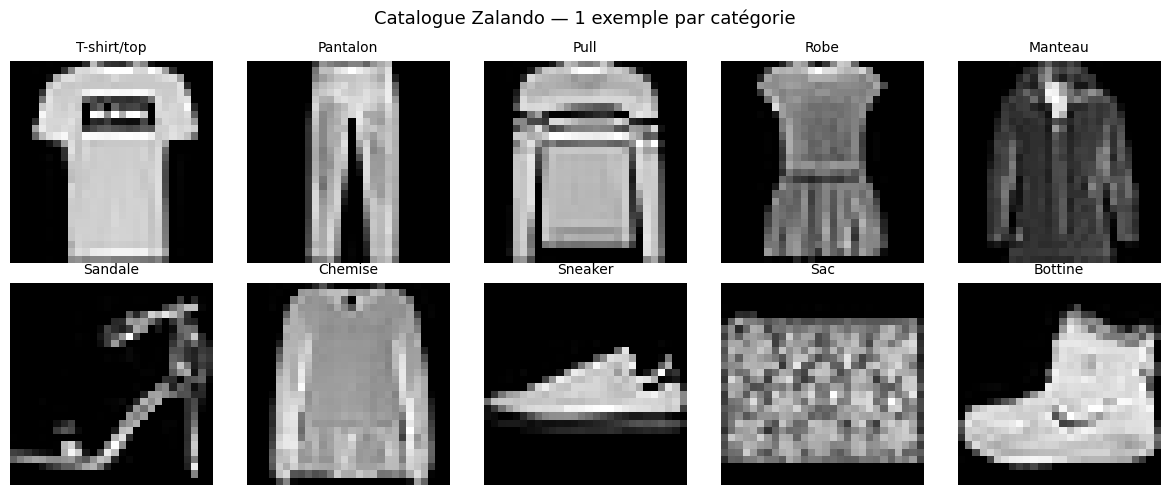

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(class_names[i], fontsize=10)
    ax.axis('off')
plt.suptitle('Catalogue Zalando — 1 exemple par catégorie', fontsize=13)
plt.tight_layout()
plt.savefig('catalogue_samples.png')
plt.show()

In [4]:
# Normalisation : [0, 255] → [0.0, 1.0]
# Les réseaux de neurones convergent mieux avec des valeurs entre 0 et 1
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32') / 255.0
print(f"Après normalisation : min={X_train_norm.min():.1f}, max={X_train_norm.max():.1f}")
# Pour scikit-learn : aplatir chaque image 28x28 en vecteur de 784 valeurs
X_train_flat = X_train_norm.reshape(-1, 784)
X_test_flat  = X_test_norm.reshape(-1, 784)
print(f"Forme pour ML classique (aplatie)  : {X_train_flat.shape}")
print(f"Forme pour réseau dense (grille)   : {X_train_norm.shape}")

Après normalisation : min=0.0, max=1.0
Forme pour ML classique (aplatie)  : (60000, 784)
Forme pour réseau dense (grille)   : (60000, 28, 28)


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
# Random Forest sur les pixels aplatis (784 features = 784 pixels individuels)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_flat, y_train)
y_pred_rf = rf.predict(X_test_flat)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest — Accuracy : {acc_rf*100:.1f}%")

Random Forest — Accuracy : 87.6%


In [6]:
#Architecture : Input(28x28) → Flatten → Dense(128) → Dense(64) → Dense(10)
model_dense = keras.Sequential([
  keras.layers.Input(shape=(28, 28)),
  keras.layers.Flatten(),
  # 28x28 → 784
  keras.layers.Dense(128, activation='relu'),   # Couche cachée 1
  keras.layers.Dense(64, activation='relu'),
  # Couche cachée 2
  keras.layers.Dense(10, activation='softmax')  # 10 catégories → probabilités
])
model_dense.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',  # Classification multi-classe avec labels entiers
  metrics=['accuracy']
)
model_dense.summary()
# Entraînement — 15% du train réservé pour la validation
history_dense = model_dense.fit(
  X_train_norm, y_train,
  epochs=15,
  batch_size=64,
  validation_split=0.15,
  verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8155 - loss: 0.5280 - val_accuracy: 0.8511 - val_loss: 0.4224
Epoch 2/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8626 - loss: 0.3812 - val_accuracy: 0.8571 - val_loss: 0.3855
Epoch 3/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8754 - loss: 0.3401 - val_accuracy: 0.8640 - val_loss: 0.3630
Epoch 4/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8842 - loss: 0.3158 - val_accuracy: 0.8763 - val_loss: 0.3471
Epoch 5/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8901 - loss: 0.2983 - val_accuracy: 0.8819 - val_loss: 0.3461
Epoch 6/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8947 - loss: 0.2837 - val_accuracy: 0.8882 - val_loss: 0.3198
Epoch 7/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8996 - loss: 0.2737 - val_accuracy: 0.8859 - val_loss: 0.3238
Epoch 8/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9034 - loss: 0.2620 - val_accuracy: 0.

In [7]:
# Ajouter la dimension canal (niveaux de gris = 1 canal, couleur RGB = 3 canaux)
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test_norm.reshape(-1, 28, 28, 1)
print(f"Forme pour CNN : {X_train_cnn.shape}")  # (60000, 28, 28, 1)
model_cnn = keras.Sequential([
  keras.layers.Input(shape=(28, 28, 1)),
  # Bloc 1 : détection de motifs simples (contours, bords)
  keras.layers.Conv2D(32, (3, 3), activation='relu'),   # 32 filtres 3x3
  keras.layers.MaxPooling2D((2, 2)),
  # Réduction spatiale
  # Bloc 2 : détection de motifs complexes (formes, structures)
  keras.layers.Conv2D(64, (3, 3), activation='relu'),   # 64 filtres 3x3
  keras.layers.MaxPooling2D((2, 2)),
  # Réduction spatiale
  # Classification finale
  keras.layers.Flatten(),
  keras.layers.Dense(64, activation='relu'),
  keras.layers.Dropout(0.3),
  keras.layers.Dense(10, activation='softmax')
])
model_cnn.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)
model_cnn.summary()
history_cnn = model_cnn.fit(
  X_train_cnn, y_train,
  epochs=10,
  batch_size=64,
  validation_split=0.15,
  verbose=1
)

Forme pour CNN : (60000, 28, 28, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.7646 - loss: 0.6465 - val_accuracy: 0.8417 - val_loss: 0.4162
Epoch 2/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8509 - loss: 0.4161 - val_accuracy: 0.8753 - val_loss: 0.3525
Epoch 3/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.8683 - loss: 0.3634 - val_accuracy: 0.8854 - val_loss: 0.3133
Epoch 4/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.8783 - loss: 0.3350 - val_accuracy: 0.8868 - val_loss: 0.3014
Epoch 5/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8876 - loss: 0.3110 - val_accuracy: 0.8958 - val_loss: 0.2866
Epoch 6/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8919 - loss: 0.2922 - val_accuracy: 0.8969 - val_loss: 0.2787
Epoch 7/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.8997 - loss: 0.2744 - val_accuracy: 0.8927 - val_loss: 0.2859
Epoch 8/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.9055 - loss: 0.2574 - 

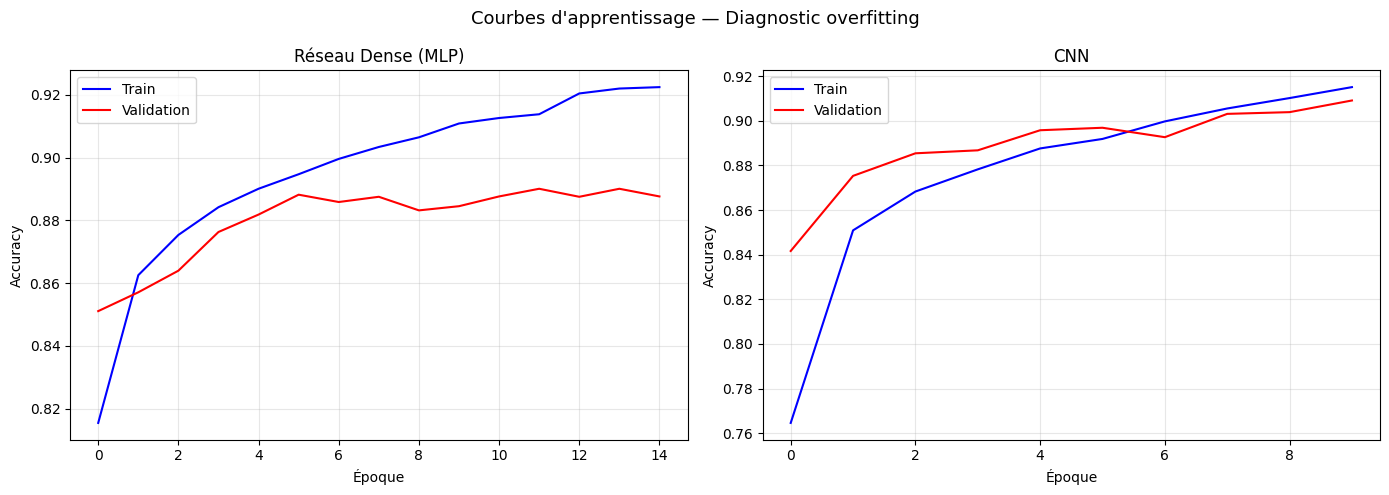

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Réseau dense
axes[0].plot(history_dense.history['accuracy'], 'b-', label='Train')
axes[0].plot(history_dense.history['val_accuracy'], 'r-', label='Validation')
axes[0].set_title('Réseau Dense (MLP)')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# CNN
axes[1].plot(history_cnn.history['accuracy'], 'b-', label='Train')
axes[1].plot(history_cnn.history['val_accuracy'], 'r-', label='Validation')
axes[1].set_title('CNN')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.suptitle('Courbes d\'apprentissage — Diagnostic overfitting', fontsize=13)
plt.tight_layout()
plt.savefig('learning_curves.png')
plt.show()

  COMPARAISON DES 3 APPROCHES — COMITÉ TECHNIQUE
  Modèle                 Accuracy  Taux erreur
-------------------------------------------------------
  Random Forest             87.6%        12.4%
  Réseau Dense              88.2%        11.8%
  CNN                       90.8%         9.2%
-------------------------------------------------------
  Objectif business : taux d'erreur < 5.0%


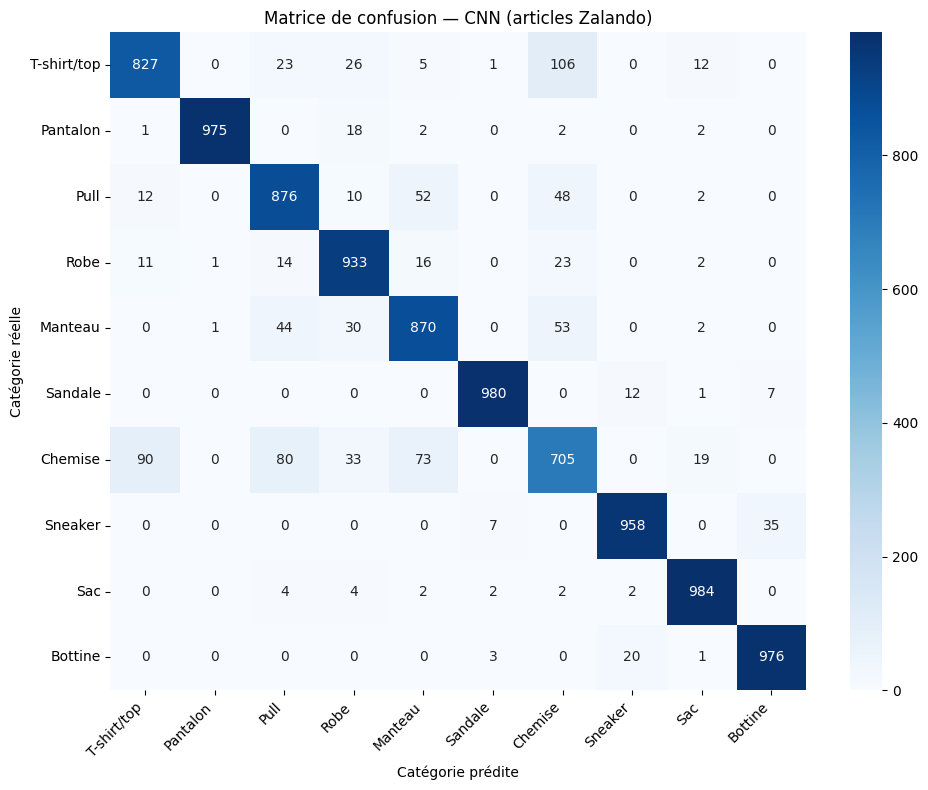


=== RAPPORT PAR CATÉGORIE — CNN ===
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.83      0.85      1000
    Pantalon       1.00      0.97      0.99      1000
        Pull       0.84      0.88      0.86      1000
        Robe       0.89      0.93      0.91      1000
     Manteau       0.85      0.87      0.86      1000
     Sandale       0.99      0.98      0.98      1000
     Chemise       0.75      0.70      0.73      1000
     Sneaker       0.97      0.96      0.96      1000
         Sac       0.96      0.98      0.97      1000
     Bottine       0.96      0.98      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [10]:
from sklearn.metrics import classification_report, confusion_matrix
# Évaluation sur le jeu de test (données jamais vues)
loss_dense, acc_dense = model_dense.evaluate(X_test_norm, y_test, verbose=0)
loss_cnn, acc_cnn     = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)
# Tableau comparatif
print("=" * 55)
print("  COMPARAISON DES 3 APPROCHES — COMITÉ TECHNIQUE")
print("=" * 55)
print(f"  {'Modèle':<20s} {'Accuracy':>10s} {'Taux erreur':>12s}")
print("-" * 55)
print(f"  {'Random Forest':<20s} {acc_rf*100:>9.1f}% {(1-acc_rf)*100:>11.1f}%")
print(f"  {'Réseau Dense':<20s} {acc_dense*100:>9.1f}% {(1-acc_dense)*100:>11.1f}%")
print(f"  {'CNN':<20s} {acc_cnn*100:>9.1f}% {(1-acc_cnn)*100:>11.1f}%")
print("-" * 55)
print(f"  Objectif business : taux d'erreur < 5.0%")
print("=" * 55)
# Prédictions du CNN pour l'analyse détaillée
y_pred_cnn     = model_cnn.predict(X_test_cnn, verbose=0)
y_pred_classes = np.argmax(y_pred_cnn, axis=1)
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de confusion — CNN (articles Zalando)')
plt.ylabel('Catégorie réelle')
plt.xlabel('Catégorie prédite')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_cnn.png')
plt.show()
# Rapport détaillé par catégorie
print("\n=== RAPPORT PAR CATÉGORIE — CNN ===")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

Erreurs : 916 / 10000 (9.2%)


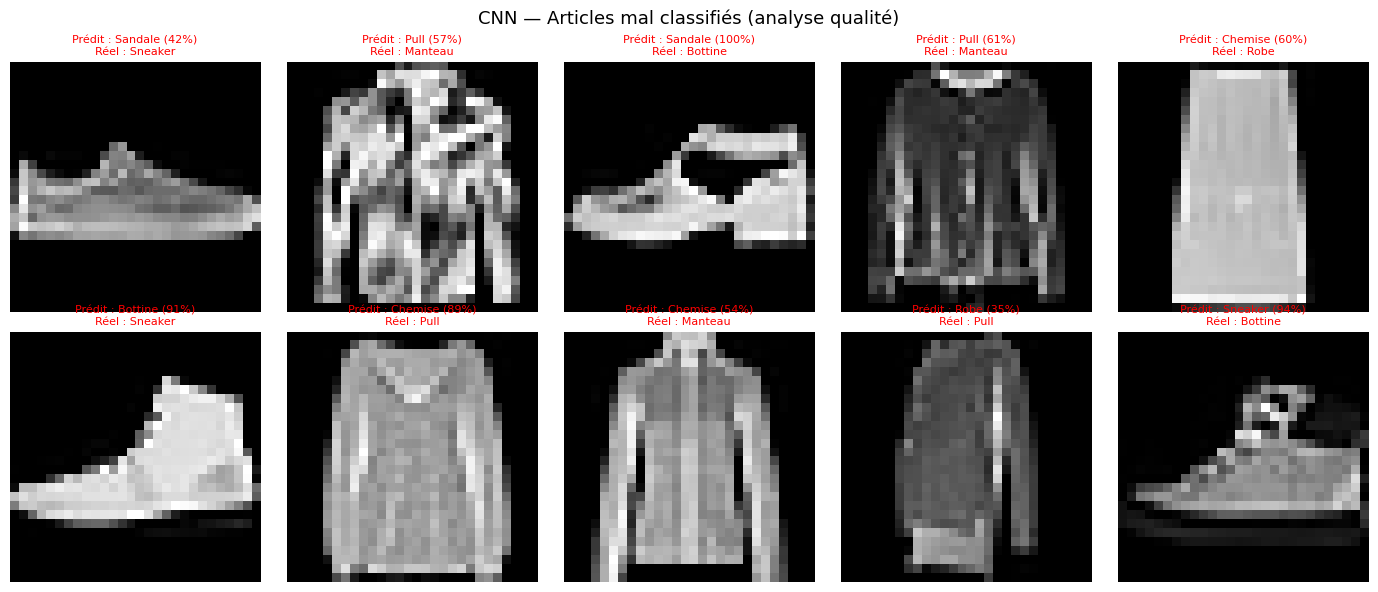


=== TOP 5 CONFUSIONS LES PLUS FRÉQUENTES ===
  T-shirt/top  → classifié comme Chemise      : 106 erreurs
  Chemise      → classifié comme T-shirt/top  : 90 erreurs
  Chemise      → classifié comme Pull         : 80 erreurs
  Chemise      → classifié comme Manteau      : 73 erreurs
  Manteau      → classifié comme Chemise      : 53 erreurs


In [11]:
# Articles mal classifiés par le CNN
errors = np.where(y_pred_classes != y_test)[0]
print(f"Erreurs : {len(errors)} / {len(y_test)} ({len(errors)/len(y_test)*100:.1f}%)")
# Afficher 10 erreurs types
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
  idx = errors[i]
  ax.imshow(X_test[idx], cmap='gray')
  # Confiance du modèle sur la prédiction erronée
  confiance = y_pred_cnn[idx, y_pred_classes[idx]] * 100
  ax.set_title(
  f"Prédit : {class_names[y_pred_classes[idx]]} ({confiance:.0f}%)\n"
  f"Réel : {class_names[y_test[idx]]}",
  fontsize=8,
  color='red'
  )
  ax.axis('off')
plt.suptitle('CNN — Articles mal classifiés (analyse qualité)', fontsize=13)
plt.tight_layout()
plt.savefig('erreurs_cnn.png')
plt.show()
# Analyse : quelles paires de catégories posent le plus de problèmes ?
print("\n=== TOP 5 CONFUSIONS LES PLUS FRÉQUENTES ===")
confusions = {}
for real, pred in zip(y_test[errors], y_pred_classes[errors]):
  pair = (class_names[real], class_names[pred])
  confusions[pair] = confusions.get(pair, 0) + 1
top_confusions = sorted(confusions.items(), key=lambda x: x[1], reverse=True)[:5]
for (real, pred), count in top_confusions:
  print(f"  {real:12s} → classifié comme {pred:12s} : {count} erreurs")

Filtres : (3, 3, 1, 32)


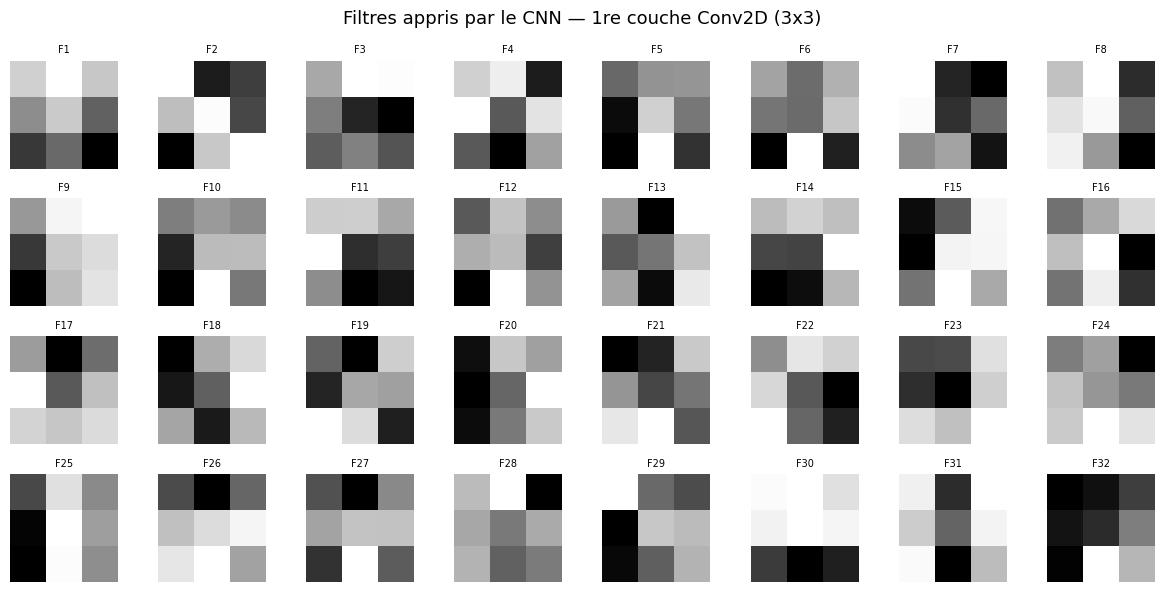

In [12]:
# Extraire les 32 filtres 3x3 de la première couche convolutive
first_conv_layer = model_cnn.layers[0]
filters, biases = first_conv_layer.get_weights()
print(f"Filtres : {filters.shape}")  # (3, 3, 1, 32) — 32 filtres de 3x3 pixels
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
  ax.imshow(filters[:, :, 0, i], cmap='gray')
  ax.set_title(f'F{i+1}', fontsize=7)
  ax.axis('off')
plt.suptitle('Filtres appris par le CNN — 1re couche Conv2D (3x3)', fontsize=13)
plt.tight_layout()
plt.savefig('filtres_conv.png')
plt.show()

Activations : (1, 26, 26, 32)


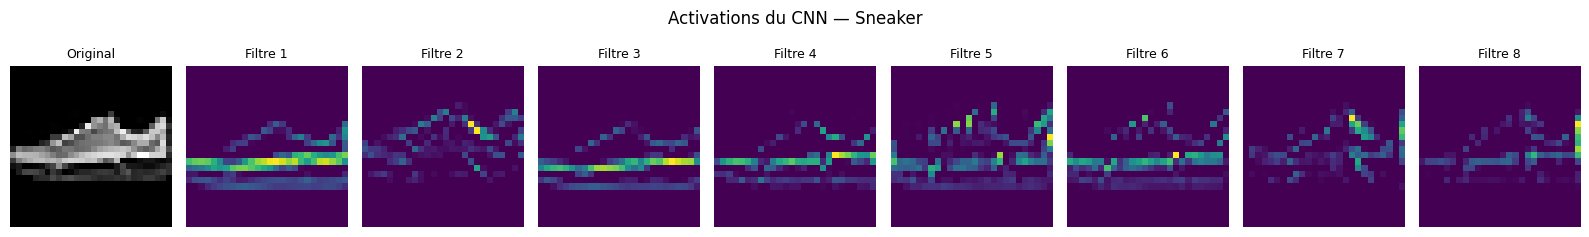

In [14]:
# Modèle intermédiaire qui renvoie les activations de la 1re couche Conv2D
activation_model = keras.Model(
    inputs=model_cnn.inputs,
    outputs=model_cnn.layers[0].output
)
# Choisir un article (Sneaker, catégorie 7)
sample_idx  = np.where(y_test == 7)[0][0]
sample      = X_test_cnn[sample_idx:sample_idx+1]
activations = activation_model.predict(sample, verbose=0)
print(f"Activations : {activations.shape}")  # (1, 26, 26, 32)
# Image originale + 8 feature maps
fig, axes = plt.subplots(1, 9, figsize=(16, 2.5))
axes[0].imshow(X_test[sample_idx], cmap='gray')
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')
for i in range(8):
    axes[i+1].imshow(activations[0, :, :, i], cmap='viridis')
    axes[i+1].set_title(f'Filtre {i+1}', fontsize=9)
    axes[i+1].axis('off')
plt.suptitle(f'Activations du CNN — {class_names[y_test[sample_idx]]}', fontsize=12)
plt.tight_layout()
plt.savefig('activations_conv.png')
plt.show()